In [ ]:
# === 1. Moi truong ===
import os, sys, time, json, math, random, subprocess, tempfile
from collections import Counter, defaultdict
from dataclasses import dataclass, field

def _has(m):
    import importlib.util as u
    return u.find_spec(m) is not None

HAVE_TORCH = _has("torch")
HAVE_TF = _has("tensorflow")
MOCK = os.environ.get("FUZZ_MOCK", "0") == "1" or not (HAVE_TORCH or HAVE_TF)
print(">> MOCK:", MOCK, "| torch:", HAVE_TORCH, "| tf:", HAVE_TF)

def _ensure(pkgs):
    import importlib.util as u
    miss = [p for p in pkgs if u.find_spec(p) is None]
    if miss:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *miss], check=False)
_ensure(["numpy", "pandas", "matplotlib"])
import numpy as np

>> MOCK: False | torch: True | tf: True


In [ ]:
# === 2. Cau hinh ===
FRAMEWORKS = (["mock"] if MOCK else
              [f for f, h in [("torch", HAVE_TORCH), ("tf", HAVE_TF)] if h])

@dataclass
class Config:
    time_budget_s: float = 120.0   # ngan sach thoi gian
    per_test_timeout: float = 6.0  # timeout moi test (giay) -> bat treo
    mem_mb: int = 3072             # gioi han bo nho tien trinh con
    cand_per_pick: int = 3         # so ung vien moi luot -> chon category hiem nhat
    rng_seed: int = 7

CFG = Config()
if MOCK:
    CFG.time_budget_s = 18.0
    CFG.per_test_timeout = 1.5
print(">> Frameworks:", FRAMEWORKS, "|", CFG)

>> Frameworks: ['torch', 'tf'] | Config(time_budget_s=120.0, per_test_timeout=6.0, mem_mb=3072, cand_per_pick=3, rng_seed=7)


## 3. Executor cách ly (subprocess)

Tiến trình cha sinh ra một *task* (JSON: framework + tên API + đặc tả input), ghi ra file tạm, rồi gọi `python _fuzz_worker.py task.json out.json` với `timeout`. Đọc kết quả qua **mã trả về**:

- `returncode < 0` → bị giết bởi tín hiệu `-returncode` (vd `-11` = SIGSEGV) → **crash thật**.
- `TimeoutExpired` → **hang** (treo).
- `returncode == 0` → đọc `out.json`: `ok` / `exception` (lành tính) / `silent_nonfinite` (âm thầm ra nan/inf) / `resource` (đụng rlimit).

Một segfault hay `os.abort()` trong tiến trình con **vượt qua** mọi `try/except` Python — đó chính là dấu hiệu lỗi native mà ta muốn bắt.

In [ ]:
# === 4. Worker (chay trong tien trinh con) + run_task (tien trinh cha) ===
WORKER_SRC = r"""
import sys, json, os

def _limits(mem_mb):
    try:
        import resource
        b = int(mem_mb) * 1024 * 1024
        resource.setrlimit(resource.RLIMIT_AS, (b, b))
        resource.setrlimit(resource.RLIMIT_CORE, (0, 0))
    except Exception:
        pass

def run_mock(api, spec):
    import ctypes
    shape = spec.get("shape", []); fill = spec.get("fill", "normal"); k = int(spec.get("k", 1))
    if api == "mock.conv2d":
        if k <= 0 or any(d < 0 for d in shape):
            os.abort()                                   # SIGABRT: tham so am
        if fill in ("inf", "nan"):
            return {"status": "silent_nonfinite", "note": "output nan/inf"}
        return {"status": "ok"}
    if api == "mock.matmul":
        if any(d > 50000000 for d in shape):
            ctypes.string_at(0)                          # SIGSEGV: doc dia chi 0
        if len(shape) < 2:
            raise ValueError("matmul yeu cau rank>=2")
        return {"status": "ok"}
    if api == "mock.softmax":
        if fill == "inf":
            return {"status": "silent_nonfinite", "note": "softmax(inf)->nan"}
        return {"status": "ok"}
    if api == "mock.reshape":
        numel = 1
        for d in shape:
            numel *= d if d > 0 else 0
        prod = 1
        for d in spec.get("target", [1]):
            if d > 0:
                prod *= d
        if prod and numel % prod:
            raise ValueError("reshape khong chia het")
        return {"status": "ok"}
    if api == "mock.slow":
        if spec.get("trigger"):
            while True:
                pass                                     # treo -> cha timeout
        return {"status": "ok"}
    raise ValueError("unknown api " + str(api))

def _torch_tensor(spec):
    import torch
    dt = getattr(torch, spec.get("dtype", "float32"))
    shape = spec.get("shape", []); fill = spec.get("fill", "normal")
    if fill == "nan":   t = torch.full(shape, float("nan"), dtype=dt)
    elif fill == "inf": t = torch.full(shape, float("inf"), dtype=dt)
    elif fill == "big": t = torch.full(shape, 1e30, dtype=dt)
    elif fill == "zeros": t = torch.zeros(shape, dtype=dt)
    else:
        t = torch.randn(shape, dtype=dt) if dt.is_floating_point else torch.randint(0, 5, shape)
    if spec.get("device") == "cuda" and torch.cuda.is_available():
        t = t.to("cuda")
    return t

def run_torch(api, spec):
    import torch
    F = torch.nn.functional
    t = _torch_tensor(spec)
    ops = {
        "torch.softmax": lambda: F.softmax(t, dim=-1),
        "torch.matmul":  lambda: torch.matmul(t, t),
        "torch.conv2d":  lambda: F.conv2d(t, torch.randn(1, (t.shape[1] if t.dim() > 1 else 1), 1, 1)),
        "torch.reshape": lambda: t.reshape(spec.get("target", [-1])),
        "torch.inv":     lambda: torch.linalg.inv(t),
        "torch.cumsum":  lambda: torch.cumsum(t, dim=-1),
    }
    out = ops[api]()
    try:
        fin = bool(torch.isfinite(out).all())
    except Exception:
        fin = True
    return {"status": "ok" if fin else "silent_nonfinite"}

def run_tf(api, spec):
    import tensorflow as tf
    shape = spec.get("shape", []); fill = spec.get("fill", "normal")
    if fill == "nan":   a = tf.fill(shape, float("nan"))
    elif fill == "inf": a = tf.fill(shape, float("inf"))
    elif fill == "big": a = tf.fill(shape, 1e30)
    elif fill == "zeros": a = tf.zeros(shape)
    else: a = tf.random.normal(shape) if shape else tf.constant(0.0)
    ops = {
        "tf.softmax": lambda: tf.nn.softmax(a, axis=-1),
        "tf.matmul":  lambda: tf.linalg.matmul(a, a),
        "tf.reshape": lambda: tf.reshape(a, spec.get("target", [-1])),
        "tf.inv":     lambda: tf.linalg.inv(a),
        "tf.cumsum":  lambda: tf.cumsum(a, axis=-1),
    }
    out = ops[api]()
    try:
        fin = bool(tf.reduce_all(tf.math.is_finite(out)).numpy()) if out.dtype.is_floating else True
    except Exception:
        fin = True
    return {"status": "ok" if fin else "silent_nonfinite"}

def main():
    task = json.load(open(sys.argv[1]))
    _limits(task.get("mem_mb", 2048))
    fw = task["framework"]; api = task["api"]; spec = task.get("args", {})
    try:
        if fw == "mock":    r = run_mock(api, spec)
        elif fw == "torch": r = run_torch(api, spec)
        elif fw == "tf":    r = run_tf(api, spec)
        else: r = {"status": "exception", "etype": "BadFramework", "msg": fw}
    except MemoryError:
        r = {"status": "resource", "note": "MemoryError (rlimit)"}
    except RecursionError:
        r = {"status": "resource", "note": "RecursionError"}
    except Exception as e:
        r = {"status": "exception", "etype": type(e).__name__, "msg": str(e)[:160]}
    json.dump(r, open(sys.argv[2], "w"))

main()
"""

WORKER_PATH = os.path.join(tempfile.gettempdir(), "_fuzz_worker.py")
with open(WORKER_PATH, "w") as f:
    f.write(WORKER_SRC)

SIGNALS = {11: "SIGSEGV", 6: "SIGABRT", 8: "SIGFPE", 4: "SIGILL", 7: "SIGBUS", 9: "SIGKILL"}

def run_task(task, timeout):
    fin = tempfile.NamedTemporaryFile("w", suffix=".json", delete=False)
    fout = tempfile.NamedTemporaryFile("w", suffix=".json", delete=False)
    json.dump(task, fin); fin.close(); fout.close()
    t0 = time.time()
    try:
        p = subprocess.run([sys.executable, WORKER_PATH, fin.name, fout.name],
                           capture_output=True, timeout=timeout)
        rc = p.returncode
        if rc < 0:
            res = {"status": "crash", "signal": SIGNALS.get(-rc, "SIG%d" % (-rc)),
                   "stderr": p.stderr.decode("utf-8", "ignore")[-160:]}
        else:
            try:
                res = json.load(open(fout.name))
            except Exception:
                res = {"status": "crash", "signal": "NO_OUTPUT",
                       "stderr": p.stderr.decode("utf-8", "ignore")[-160:]}
    except subprocess.TimeoutExpired:
        res = {"status": "hang"}
    res["elapsed"] = round(time.time() - t0, 3)
    for nm in (fin.name, fout.name):
        try: os.unlink(nm)
        except Exception: pass
    return res

print(">> Worker da ghi:", WORKER_PATH)

>> Worker da ghi: /tmp/_fuzz_worker.py


In [ ]:
# === 5. Bo sinh input bien (edge-case generators) ===
DTYPES = ["float32", "float64", "int32", "int64"]
FILLS  = ["normal", "zeros", "nan", "inf", "big"]

def rand_shape(rng, allow_bad=True):
    rank = rng.choice([0, 1, 2, 3, 4, 5])
    dims = []
    for _ in range(rank):
        c = rng.random()
        if allow_bad and c < 0.12:   dims.append(-rng.randint(1, 4))         # chieu am
        elif allow_bad and c < 0.18: dims.append(0)                          # chieu rong
        elif allow_bad and c < 0.22: dims.append(rng.choice([10**8, 10**9])) # khong lo
        else:                        dims.append(rng.randint(1, 8))
    return dims

def gen_args(rng, api):
    spec = {"shape": rand_shape(rng), "dtype": rng.choice(DTYPES),
            "fill": rng.choice(FILLS), "device": rng.choice(["cpu", "cpu", "cuda"])}
    if "reshape" in api: spec["target"] = rand_shape(rng) or [-1]
    if "conv2d" in api:  spec["k"] = rng.choice([-1, 0, 1, 3])
    if "slow" in api:    spec["trigger"] = (rng.random() < 0.15)
    return spec

def categ(spec):
    shp = spec["shape"]
    bad = any((d < 0 or d == 0 or d >= 10**8) for d in shp)
    return (min(len(shp), 5), spec["fill"], spec["dtype"], "bad" if bad else "ok", spec["device"])

In [ ]:
# === 6. Bang API (registry) ===
API_TABLE = {
    "mock":  ["mock.conv2d", "mock.matmul", "mock.softmax", "mock.reshape", "mock.slow"],
    "torch": ["torch.softmax", "torch.matmul", "torch.conv2d", "torch.reshape", "torch.inv", "torch.cumsum"],
    "tf":    ["tf.softmax", "tf.matmul", "tf.reshape", "tf.inv", "tf.cumsum"],
}
def all_apis(frameworks):
    out = []
    for fw in frameworks:
        for a in API_TABLE.get(fw, []):
            out.append((fw, a))
    return out
print(">> So API se fuzz:", len(all_apis(FRAMEWORKS)))

>> So API se fuzz: 11


In [ ]:
# === 7. Coverage-lite (huong category hiem) ===
class Cov:
    def __init__(self):
        self.seen = Counter()
    def sig(self, fw, api, spec):
        return (fw, api) + categ(spec)
    def update(self, s):
        new = s not in self.seen
        self.seen[s] += 1
        return new
    def count(self):
        return len(self.seen)

In [ ]:
# === 8. Vong lap fuzz chinh ===
def fuzz(frameworks, cfg):
    rng = random.Random(cfg.rng_seed)
    cov = Cov()
    apis = all_apis(frameworks)
    acount = Counter()
    crashes, seen_crash, curve = [], set(), []
    stats = Counter()
    t0 = time.time(); it = 0

    while time.time() - t0 < cfg.time_budget_s:
        it += 1
        # chon API uu tien it duoc tham (kham pha deu)
        ws = [1.0 / (1 + acount[a]) for a in apis]
        fw, api = rng.choices(apis, weights=ws, k=1)[0]
        # sinh vai ung vien, chon nhom input hiem nhat (coverage-guided)
        cands = [gen_args(rng, api) for _ in range(cfg.cand_per_pick)]
        spec = min(cands, key=lambda s: cov.seen[cov.sig(fw, api, s)])
        acount[(fw, api)] += 1
        cov.update(cov.sig(fw, api, spec))

        r = run_task({"framework": fw, "api": api, "args": spec, "mem_mb": cfg.mem_mb},
                     cfg.per_test_timeout)
        stats[r["status"]] += 1

        if r["status"] in ("crash", "hang"):
            key = (fw, api, r["status"], r.get("signal", ""))
            if key not in seen_crash:
                seen_crash.add(key)
                crashes.append({"iter": it, "framework": fw, "api": api,
                                "status": r["status"], "signal": r.get("signal", ""),
                                "elapsed": r.get("elapsed"), "spec": spec,
                                "stderr": r.get("stderr", "")[-140:]})
        bugs = stats["crash"] + stats["hang"]
        curve.append((it, len(seen_crash), bugs))
        if it % 25 == 0:
            print("[it %4d] tests=%4d  unique_bugs=%2d  crash+hang=%4d  ok=%4d  exc=%4d  nonfinite=%4d  t=%4.1fs"
                  % (it, it, len(seen_crash), bugs, stats["ok"], stats["exception"],
                     stats["silent_nonfinite"], time.time() - t0))

    print("\n>> XONG: %d test | %d BUG DUY NHAT | %d nhom-input | stats=%s"
          % (it, len(seen_crash), cov.count(), dict(stats)))
    return {"crashes": crashes, "curve": curve, "stats": dict(stats),
            "total": it, "seen": len(seen_crash), "covcats": cov.count()}

In [ ]:
# === 9. Chay fuzzer ===
RESULT = fuzz(FRAMEWORKS, CFG)

[it   25] tests=  25  unique_bugs= 3  crash+hang=   3  ok=   2  exc=  19  nonfinite=   1  t=66.7s

>> XONG: 45 test | 4 BUG DUY NHAT | 45 nhom-input | stats={'exception': 37, 'hang': 4, 'ok': 2, 'silent_nonfinite': 2}


Bug DUY NHAT: 4 | Tong test: 45 | Nhom input da phu: 45
Phan bo trang thai: {'exception': 37, 'hang': 4, 'ok': 2, 'silent_nonfinite': 2}

Bang bug (framework | api | loai | tin hieu):
framework  api         status  signal
tf         tf.cumsum   hang              1
           tf.inv      hang              1
           tf.matmul   hang              1
           tf.softmax  hang              1


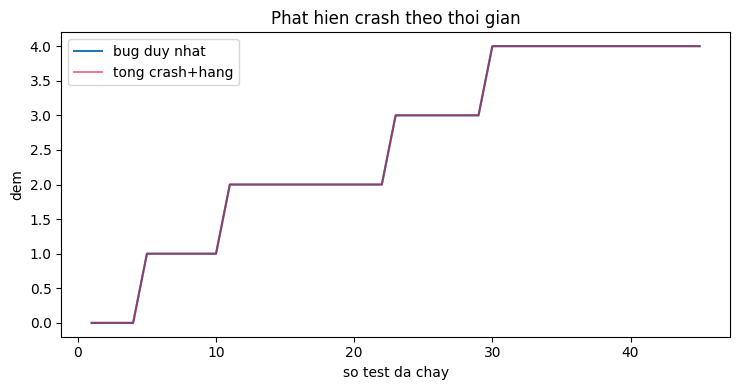


>> Da luu: crashes.jsonl | crash_report.png | repro_snippets.txt


,iter,framework,api,status,signal,elapsed,spec,stderr
0,5,tf,tf.softmax,hang,,6.020,"{'shape': [1, 7], 'dtype': 'int64', 'fill': 'i...",
1,11,tf,tf.cumsum,hang,,6.030,"{'shape': [5, 8, 4, 5], 'dtype': 'float64', 'f...",
2,23,tf,tf.matmul,hang,,6.041,"{'shape': [], 'dtype': 'int64', 'fill': 'inf',...",
3,30,tf,tf.inv,hang,,6.033,"{'shape': [8], 'dtype': 'float32', 'fill': 'in...",


In [ ]:
# === 10. Bao cao + repro ===
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt

print("Bug DUY NHAT:", RESULT["seen"], "| Tong test:", RESULT["total"],
      "| Nhom input da phu:", RESULT["covcats"])
print("Phan bo trang thai:", RESULT["stats"])

df = pd.DataFrame(RESULT["crashes"])
if len(df):
    print("\nBang bug (framework | api | loai | tin hieu):")
    print(df.groupby(["framework", "api", "status", "signal"]).size().to_string())

cc = np.array(RESULT["curve"], dtype=float)
plt.figure(figsize=(7.5, 4))
if len(cc):
    plt.plot(cc[:, 0], cc[:, 1], label="bug duy nhat")
    plt.plot(cc[:, 0], cc[:, 2], color="crimson", alpha=0.55, label="tong crash+hang")
plt.legend(); plt.xlabel("so test da chay"); plt.ylabel("dem")
plt.title("Phat hien crash theo thoi gian"); plt.tight_layout()
plt.savefig("crash_report.png", dpi=110); plt.show()

# luu ket qua + sinh snippet tai hien (reproducer)
with open("crashes.jsonl", "w", encoding="utf-8") as f:
    for r in RESULT["crashes"]:
        f.write(json.dumps(r, ensure_ascii=False) + "\n")

def repro(r):
    task = {"framework": r["framework"], "api": r["api"], "args": r["spec"], "mem_mb": 3072}
    return ("# [%s | %s] %s\nrun_task(%s, timeout=6.0)\n"
            % (r["status"], r.get("signal", ""), r["api"], json.dumps(task, ensure_ascii=False)))
with open("repro_snippets.txt", "w", encoding="utf-8") as f:
    f.write("\n".join(repro(r) for r in RESULT["crashes"][:80]))

print("\n>> Da luu: crashes.jsonl | crash_report.png | repro_snippets.txt")
try:
    from IPython.display import display
    if len(df): display(df.head(15))
except Exception:
    pass